# 05 — Feature Engineering & Selection

Goal: go from 442 cleaned sensors to a defensible, ranked shortlist of failure-driving sensors,
using a model-based importance ranking (to be statistically validated afterwards in notebook 07).

**Decision: Random Forest importance over correlation ranking.**
Notebook 04 showed many sensors are highly inter-correlated. A simple "correlation with label"
ranking would surface redundant sensors that all measure the same underlying effect. A Random
Forest's impurity-based importance accounts for interactions and redundancy better, at the cost
of being less immediately interpretable — which is exactly why notebook 07 exists, to validate
the resulting shortlist with a simple, transparent statistical test.


In [1]:

import sys
sys.path.insert(0, "../src")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import modeling as mdl
import visualization as viz

df = pd.read_csv("../data/processed/secom_cleaned.csv")
sensor_cols = [c for c in df.columns if c not in ("Time", "Pass/Fail")]
X = df[sensor_cols]
y = df["Pass/Fail"]
print("X:", X.shape, "| y class balance:\n", y.value_counts())


X: (1567, 442) | y class balance:
 Pass/Fail
-1    1463
 1     104
Name: count, dtype: int64


## Train/test split

**Decision: stratified 75/25 split.**
With only 104 fail examples total, stratification ensures both train and test sets keep the
same ~6.6% fail rate — an unstratified split risks a test set with very few (or zero) fail
examples, making evaluation unreliable.

In [2]:

X_train, X_test, y_train, y_test = mdl.make_train_test_split(X, y, test_size=0.25)
print("Train:", X_train.shape, "| fail rate:", round(100*(y_train==1).mean(),2), "%")
print("Test: ", X_test.shape, "| fail rate:", round(100*(y_test==1).mean(),2), "%")


Train: (1175, 442) | fail rate: 6.64 %
Test:  (392, 442) | fail rate: 6.63 %


## Fitting a Random Forest for feature ranking

**Decision: `class_weight="balanced"` rather than SMOTE/oversampling at this stage.**
Balanced class weights are a one-line, easily explained adjustment: the model penalizes
mistakes on the minority (fail) class more heavily during training, without synthesizing new
data points. SMOTE is noted in the decision log as a reasonable alternative worth testing, but
adds a layer of synthetic-data complexity that isn't needed to get a first honest read on
feature importance.

In [3]:

rf = mdl.build_random_forest(n_estimators=400)
rf.fit(X_train, y_train)

importances = mdl.get_feature_importance(rf, sensor_cols)
print("Top 15 sensors by Random Forest importance:")
print(importances.head(15))


Top 15 sensors by Random Forest importance:
59     0.016981
103    0.015582
33     0.012229
130    0.008641
351    0.007785
213    0.007504
21     0.007317
577    0.007230
477    0.007225
341    0.006954
64     0.006892
183    0.006800
31     0.006793
510    0.006067
65     0.005753
dtype: float64


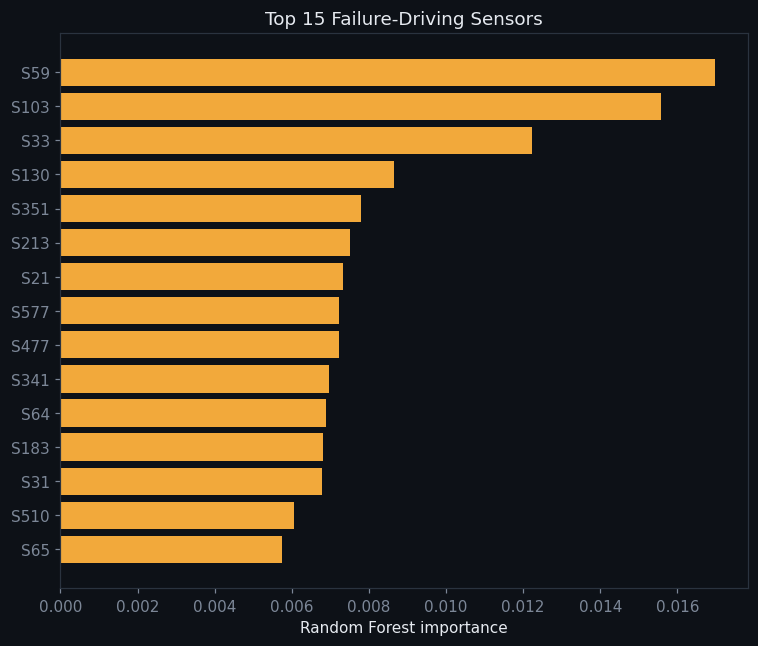

In [4]:

fig, ax = plt.subplots(figsize=(7,6))
viz.plot_feature_importance(importances, top_n=15, ax=ax)
plt.tight_layout()
plt.show()


In [5]:

top15 = importances.head(15)
top15.to_csv("../data/processed/feature_importance_top15.csv", header=["importance"])
importances.to_csv("../data/processed/feature_importance_full.csv", header=["importance"])
print("Saved top-15 and full importance rankings to data/processed/")


Saved top-15 and full importance rankings to data/processed/


## Summary

The top-15 sensors by Random Forest importance are carried forward into notebook 06 (where the
full-feature model performance is evaluated) and notebook 07 (where each of these sensors is
statistically tested for a genuine pass/fail distributional difference, with correction for
testing many sensors at once).